# Concept

```{contents}
:local:
```

In [1]:
import sys
from pathlib import Path
parent_dir = str(Path().resolve().parents[3])
sys.path.append(parent_dir)

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In the previous chapter on Bernoulli, we say that given a true population, what
is the probability of a randomly drawn person has covid? This probability $p$ is
the parameter of the Bernoulli.

Now we ask, if we sample $n$ people from the true population, and these $n$
samples are **i.i.d.**, and are also $n$ indepenedent Bernoulli trials. Then we
ask, what's the number of successes in $n$ such samples?

Instead of asking the question, what is the probability of **a single randomly
drawn person** having covid, we ask, if we randomly drawn $n$ people
independently, what is the probability of exactly $k <= n$ people having covid?

The distinction is a single random draw vs $n$ i.i.d. draws.

## PMF and CDF of Binomial Distribution

```{prf:definition} Bernoulli Trials
:label: def:bernoulli_trials_2

A **Bernoulli trial** is an **experiment** with two possible outcomes: success or failure, often
denoted as 1 or 0 respectively.

The three assumptions for Bernoulli trials are:

1. Each trial has two possible outcomes: 1 or 0 (success of failure);
2. The probability of success ($p$) is constant for each trial and so is the failure ($1-p$);
3. Each trial is independent; The outcome of previous trials has no influence on any subsequent trials.

See more [here](https://www.statisticshowto.com/bernoulli-trials/).
```

```{prf:definition} Binomial Distribution (PMF)
:label: def_binomial_distribution_pmf

Let $X$ be a **Binomial random variable** with parameters $n$ and $p$. Then the
probability mass function (PMF) of $X$ is given by

$$
\P \lsq X = k \rsq = \binom{n}{k} p^k (1-p)^{n-k} \qquad \text{for } k = 0, 1, \ldots, n
$$

where $0 \leq p \leq 1$ is called the binomial parameter, and $n$ is the ***total number of trials***.

Some conventions:

1. We denote $X \sim \binomial(n, p)$ if $X$ follows the binomial distribution with parameters $p$ of size $n$.
2. $n$ is typically the number of trials, but in this book it is also stated as the number of states, this makes sense
because $X$ can only take on $n$ states (outcomes).
3. Binomial distribution is defined by two parameters $n$ and $p$.
```

```{prf:definition} The State Space of Binomial Distribution
:label: def:state_space_binomial

The state space of a binomial random variable $X$ is $\{0, 1, \ldots, n\}$.
```

```{prf:definition} Binomial Distribution (CDF)
:label: def_binomial_distribution_cdf

Let $X$ be a **Binomial random variable** with parameters $n$ and $p$. Then the
cumulative distribution function (CDF) of $X$ is given by

$$
\cdf(k) = \P \lsq X \leq k \rsq = \sum_{\ell=0}^k \binom{n}{i} p^{\ell} (1-p)^{n-\ell}
$$

where $0 \leq p \leq 1$ is called the binomial parameter, and $n$ is the ***total number of trials***.
```

## Plotting PMF and CDF of Binomial Distribution

The below plot shows the PMF and its Empirical Histogram distribution for
parameters $n=10$ and $p=0.5$, with the latter consisting of 5000 samples drawn
from a binomial distribution.

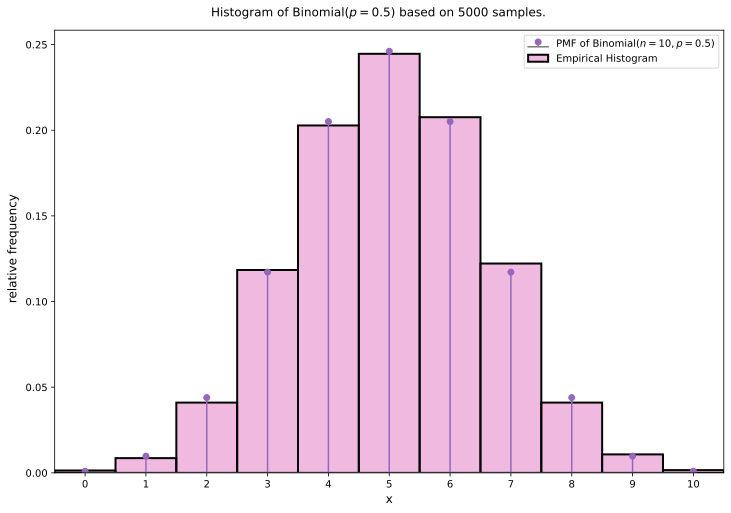

In [2]:
from omnivault.utils.probability_theory.plot import plot_binomial_pmfs, plot_empirical_binomial

_fig, ax = plt.subplots(1, figsize=(12, 8), dpi=125)
plot_binomial_pmfs(ns=[10], ps=[0.5], ax=ax)
plot_empirical_binomial(n=10, p=0.5, size=5000, ax=ax)
plt.show()

The below plots show the PMF and CDF of binomial distribution for different
values of $n$ and $p$. More specifically, when we fix $n=60$ and $p$ varies, and
when we fix $p=0.5$ and $n$ varies.

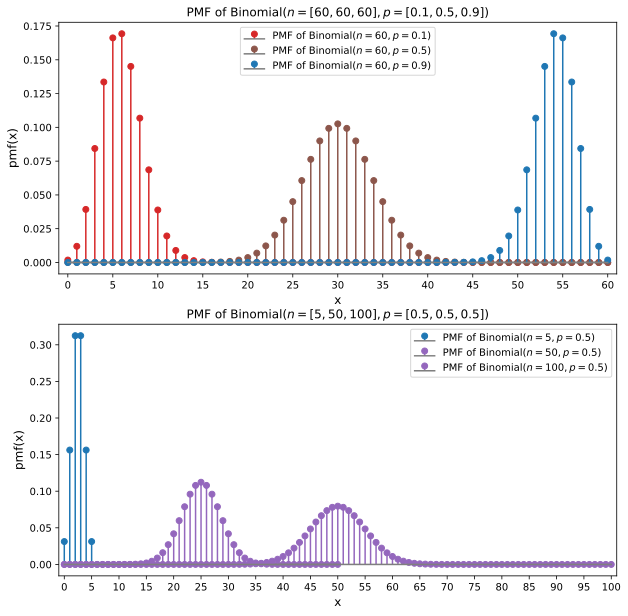

In [3]:
from omnivault.utils.probability_theory.plot import plot_binomial_pmfs

_fig, axes = plt.subplots(2, 1, figsize=(10, 10), dpi=125)
plot_binomial_pmfs(ns=[60, 60, 60], ps=[0.1, 0.5, 0.9], ax=axes[0])
plot_binomial_pmfs(ns=[5, 50, 100], ps=[0.5, 0.5, 0.5], ax=axes[1])
plt.show()

## Assumptions

The three assumptions for Bernoulli trials are:

1. Each trial has two possible outcomes: 1 or 0 (success of failure);
2. The probability of success ($p$) is constant for each trial and so is the
   failure ($1-p$);
3. Each trial is independent; The outcome of previous trials has no influence on
   any subsequent trials.

## Expectation and Variance

```{prf:property} Expectation of Binomial Distribution
:label: prop:bino_exp

Let $X \sim \binomial(n, p)$ be a Binomial random variable with parameters $n$ and $p$.
Then the expectation of $X$ is given by

$$
\begin{align}
\expectation \lsq X \rsq = np
\end{align}
$$
```

```{prf:property} Variance of Binomial Distribution
:label: prop:bino_var

Let $X \sim \binomial(n, p)$ be a Binomial random variable with parameters $n$ and $p$.
Then the variance of $X$ is given by

$$
\begin{align}
\var \lsq X \rsq = np(1-p)
\end{align}
$$
```

## Binomial Distribution as a Sum of Bernoulli Trials

```{prf:definition} Binomial Distribution as a Sum of Bernoulli Trials
:label: def:binomial_as_sum_of_bernoulli

Let us define $X_1, X_2, \ldots, X_n$ to be $n$ independent Bernoulli trials with parameter $p$
(i.e. $X_i \sim \bern(p)$).

Then the random variable $X = X_1 + X_2 + \cdots + X_n$ is a Binomial random variable with parameters $n$ and $p$.
```

## Further Readings

-   Chan, Stanley H. "Chapter 3.5.2. Binomial random variable." In Introduction
    to Probability for Data Science, 143-149. Ann Arbor, Michigan: Michigan
    Publishing Services, 2021.